## Análise exploratória de Dados
Título da pesquisa: Predição de Acidentes em Rodovias Federais de Santa Catarina por Meio de Séries Temporais e Aprendizado de Máquina.

Apesar da PRF disponibilizar dados desde 2007, para nossa análise consideraremos os dados de 2022 a 2026, visto que ao longo dos anos as rodovias sofreram muitas mudanças e também que em 2020 e 2021 a pandemia impactou na quantidade de veículos nas rodovias, alterando padrões de acidentes.

Perguntas importantes para o processo: 
1. O que estamos tentando prever/resolver? 
2. Que tipo de dados temos e como trataremos cada um deles?
3. Há missing values? Se sim, como trataremos? 
4. Temos outliers? 
5. Quais features podemos fazer para extrair mais dos dados? 

## Importações e Carregamento de dados

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
acidentes_SC = pd.read_parquet(Path('../data/interim/acidentes_SC.parquet'))

## Tipagem e estatísticas de colunas

In [3]:
# .info() nos dá nome e tipo dos dados das colunas da tabela
acidentes_SC.info()

<class 'pandas.DataFrame'>
RangeIndex: 35497 entries, 0 to 35496
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      35497 non-null  Int64         
 1   data_inversa            35497 non-null  datetime64[us]
 2   dia_semana              35497 non-null  str           
 3   br                      35497 non-null  int64         
 4   municipio               35497 non-null  str           
 5   causa_acidente          35497 non-null  str           
 6   tipo_acidente           35497 non-null  str           
 7   classificacao_acidente  35497 non-null  str           
 8   fase_dia                35497 non-null  str           
 9   condicao_metereologica  35497 non-null  str           
 10  mortos                  35497 non-null  int64         
 11  feridos_leves           35497 non-null  int64         
 12  feridos_graves          35497 non-null  int64         
 1

In [4]:
# .describe() fornece informações de média, desvio padrão, valor min e max e quartis de colunas númericas
acidentes_SC.describe()

,id,data_inversa,br,mortos,feridos_leves,feridos_graves,feridos,veiculos
count,35497.0,35497,35497.000000,35497.000000,35497.000000,35497.000000,35497.000000,35497.000000
mean,596790.073105,2024-04-03 18:39:38.634814,204.275573,0.048737,0.871116,0.259149,1.130265,1.975716
min,405165.0,2022-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,509257.0,2023-02-28 00:00:00,101.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,594669.0,2024-04-14 00:00:00,101.000000,0.000000,1.000000,0.000000,1.000000,2.000000
75%,691218.0,2025-05-11 00:00:00,282.000000,0.000000,1.000000,0.000000,1.000000,2.000000
max,778425.0,2026-05-31 00:00:00,480.000000,5.000000,37.000000,18.000000,38.000000,31.000000
std,104197.371283,NaN,133.618185,0.249051,0.884395,0.565396,0.932680,0.963982


## Gráficos
Analisando quais cidades, brs tem quantidade maior de acidentes

In [5]:
ranking_br = acidentes_SC['br'].value_counts().reset_index()
ranking_br.columns = ['BR', 'Total_Acidentes']

print("Ranking de BRs com maior número de acidentes entre 2022 e 2026:")
print(ranking_br.head(5))

Ranking de BRs com maior número de acidentes entre 2022 e 2026:
    BR  Total_Acidentes
0  101            18368
1  282             5818
2  470             4917
3  280             3424
4  116             1512


In [6]:
ranking_br = acidentes_SC['municipio'].value_counts().reset_index()
ranking_br.columns = ['Municipio', 'Total_Acidentes']

print("Ranking de Cidades com maior número de acidentes entre 2022 e 2026:")
print(ranking_br.head(5))

Ranking de Cidades com maior número de acidentes entre 2022 e 2026:
            Municipio  Total_Acidentes
0            sao jose             3262
1             palhoca             2483
2              itajai             1681
3  balneario camboriu             1384
4            araquari             1316


--- Top 15 Causas de Acidentes em SC ---
                                       causa_acidente  total_acidentes
0            reacao tardia ou ineficiente do condutor             5187
1                      ausencia de reacao do condutor             4555
2   acessar a via sem observar a presenca dos outr...             3804
3   condutor deixou de manter distancia do veiculo...             2568
4                    ingestao de alcool pelo condutor             2541
5                             velocidade incompativel             2266
6                         manobra de mudanca de faixa             2261
7            desrespeitar a preferencia no cruzamento             1280
8                              transitar na contramao             1204
9                demais falhas mecanicas ou eletricas             1197
10  trafegar com motocicleta (ou similar) entre as...             1137
11                             ultrapassagem indevida              815
12                                  

/var/folders/r8/qb8zf7yj7yv2dnhf6g2dvg_c0000gn/T/ipykernel_6540/3841582399.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


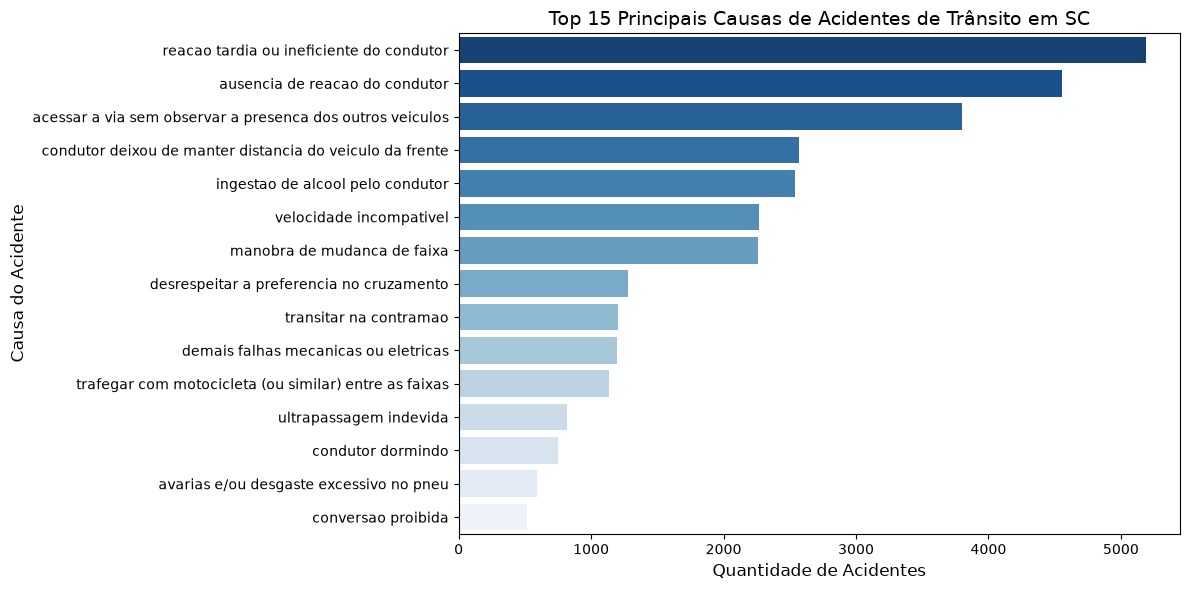

In [21]:
ranking_causas = (
    acidentes_SC['causa_acidente']
    .value_counts()
    .reset_index(name='total_acidentes')
)
ranking_causas.columns = ['causa_acidente', 'total_acidentes']

# Exibe as 15 principais causas na tela
print("--- Top 15 Causas de Acidentes em SC ---")
print(ranking_causas.head(15))

# Plotagem do Gráfico de Barras
plt.figure(figsize=(12, 6))
sns.barplot(
    data=ranking_causas.head(15),
    x='total_acidentes',
    y='causa_acidente',
    palette='Blues_r',
)

plt.title('Top 15 Principais Causas de Acidentes de Trânsito em SC', fontsize=14)
plt.xlabel('Quantidade de Acidentes', fontsize=12)
plt.ylabel('Causa do Acidente', fontsize=12)
plt.tight_layout()
plt.savefig(Path('../docs/graphics/top_causas_acidentes'), dpi=300)
plt.show()

/var/folders/r8/qb8zf7yj7yv2dnhf6g2dvg_c0000gn/T/ipykernel_6540/925233304.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


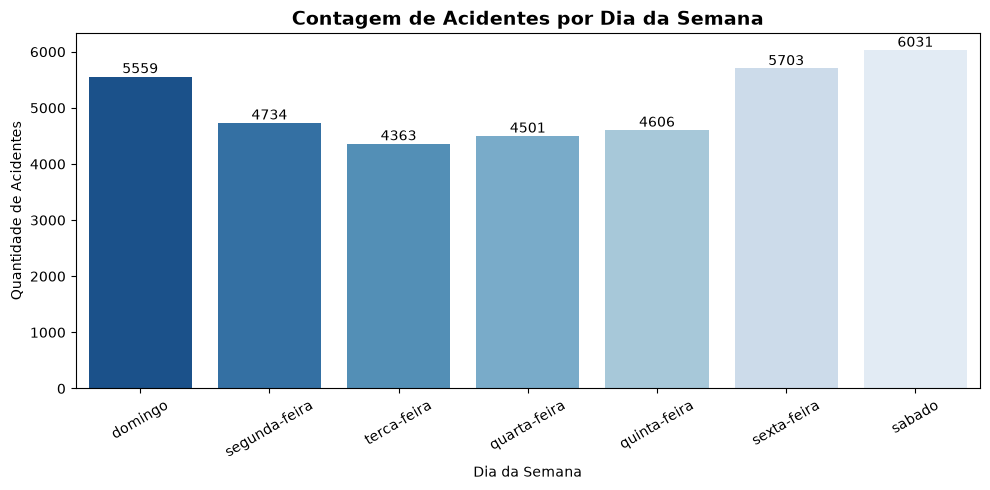

In [20]:
# Contagem de acidentes em cada dia da semana (Gráfico de Barras)
ordem_dias = ['domingo', 'segunda-feira', 'terca-feira', 'quarta-feira', 'quinta-feira', 'sexta-feira', 'sabado']

plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=acidentes_SC, 
    x='dia_semana', 
    order=ordem_dias, 
    palette='Blues_r'
)
plt.title('Contagem de Acidentes por Dia da Semana', fontsize=14, fontweight='bold')
plt.xlabel('Dia da Semana')
plt.ylabel('Quantidade de Acidentes')
plt.xticks(rotation=30)
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig(Path('../docs/graphics/qtd_acidentes_por_dia'), dpi=300)
plt.show()

/var/folders/r8/qb8zf7yj7yv2dnhf6g2dvg_c0000gn/T/ipykernel_6540/2958614086.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


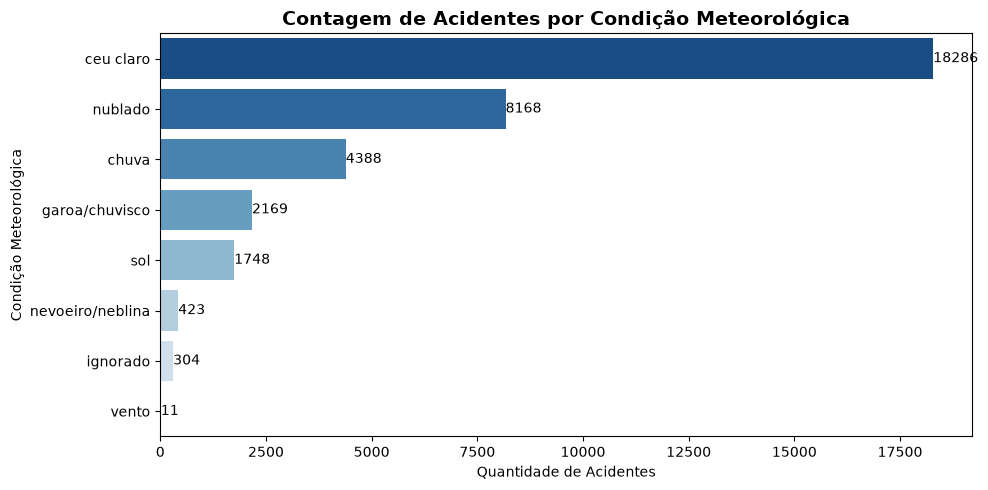

In [19]:
# Contagem de acidentes por condição meteorológica (Gráfico de Barras)

plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=acidentes_SC, 
    y='condicao_metereologica', 
    order=acidentes_SC['condicao_metereologica'].value_counts().index, 
    palette='Blues_r'
)
plt.title('Contagem de Acidentes por Condição Meteorológica', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Acidentes')
plt.ylabel('Condição Meteorológica')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig(Path('../docs/graphics/acidentes_por_cond_met'), dpi=300)
plt.show()

/var/folders/r8/qb8zf7yj7yv2dnhf6g2dvg_c0000gn/T/ipykernel_6540/2097029103.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


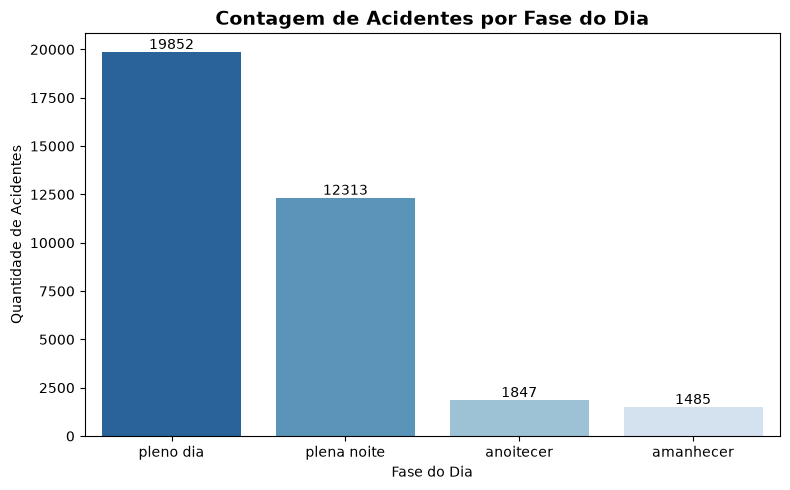

In [18]:
# Contagem de acidentes por fase do dia (Gráfico de Barras)
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=acidentes_SC, 
    x='fase_dia', 
    order=acidentes_SC['fase_dia'].value_counts().index, 
    palette='Blues_r'
)
plt.title('Contagem de Acidentes por Fase do Dia', fontsize=14, fontweight='bold')
plt.xlabel('Fase do Dia')
plt.ylabel('Quantidade de Acidentes')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig(Path('../docs/graphics/acidentes_por_fasedia'), dpi=300)
plt.show()

/var/folders/r8/qb8zf7yj7yv2dnhf6g2dvg_c0000gn/T/ipykernel_6540/392481584.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


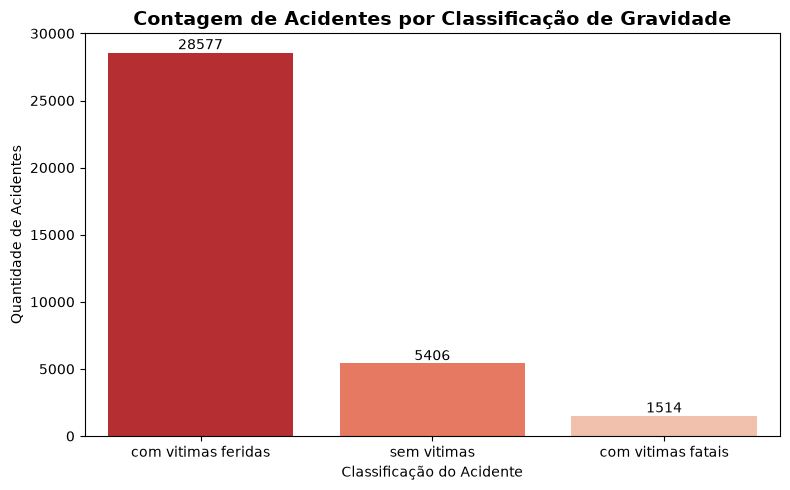

In [17]:
# Contagem de acidentes por classificação do acidente (Gráfico de Barras)
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=acidentes_SC, 
    x='classificacao_acidente', 
    order=acidentes_SC['classificacao_acidente'].value_counts().index, 
    palette='Reds_r'
)
plt.title('Contagem de Acidentes por Classificação de Gravidade', fontsize=14, fontweight='bold')
plt.xlabel('Classificação do Acidente')
plt.ylabel('Quantidade de Acidentes')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.savefig(Path('../docs/graphics/acidentes_por_gravidade'), dpi=300)
plt.show()

/var/folders/r8/qb8zf7yj7yv2dnhf6g2dvg_c0000gn/T/ipykernel_6540/4023284930.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=mortos_por_ano, x="ano", y="mortos", palette="Reds_r")


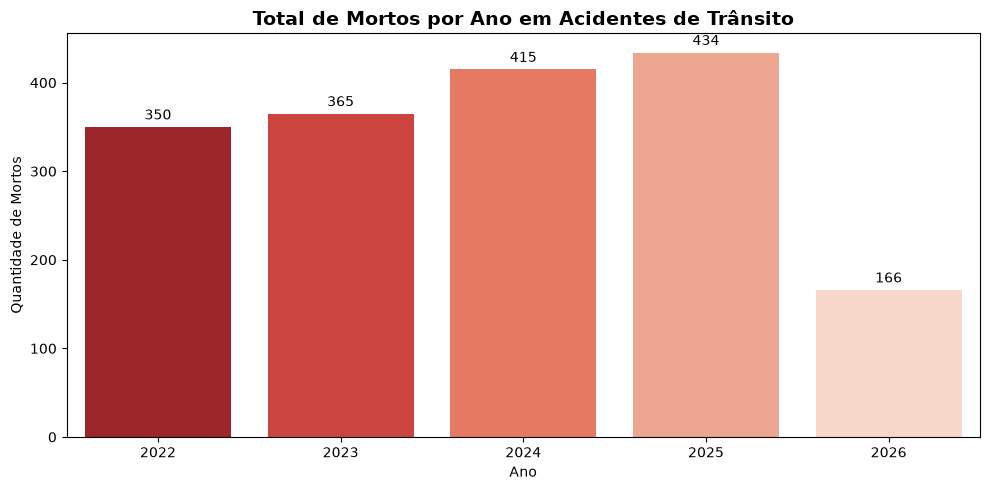

In [16]:
# GRÁFICO DE MORTOS POR ANO (Gráfico de Barras)
acidentes_SC["ano"] = acidentes_SC["data_inversa"].dt.year

# Agrupa somando o total de mortos por ano
mortos_por_ano = acidentes_SC.groupby("ano")["mortos"].sum().reset_index()

plt.figure(figsize=(10, 5))
ax1 = sns.barplot(data=mortos_por_ano, x="ano", y="mortos", palette="Reds_r")

plt.title(
    "Total de Mortos por Ano em Acidentes de Trânsito",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Ano")
plt.ylabel("Quantidade de Mortos")

for container in ax1.containers:
  ax1.bar_label(container, padding=3)

plt.tight_layout()
plt.savefig(Path('../docs/graphics/total_mortos_por_ano'), dpi=300)
plt.show()

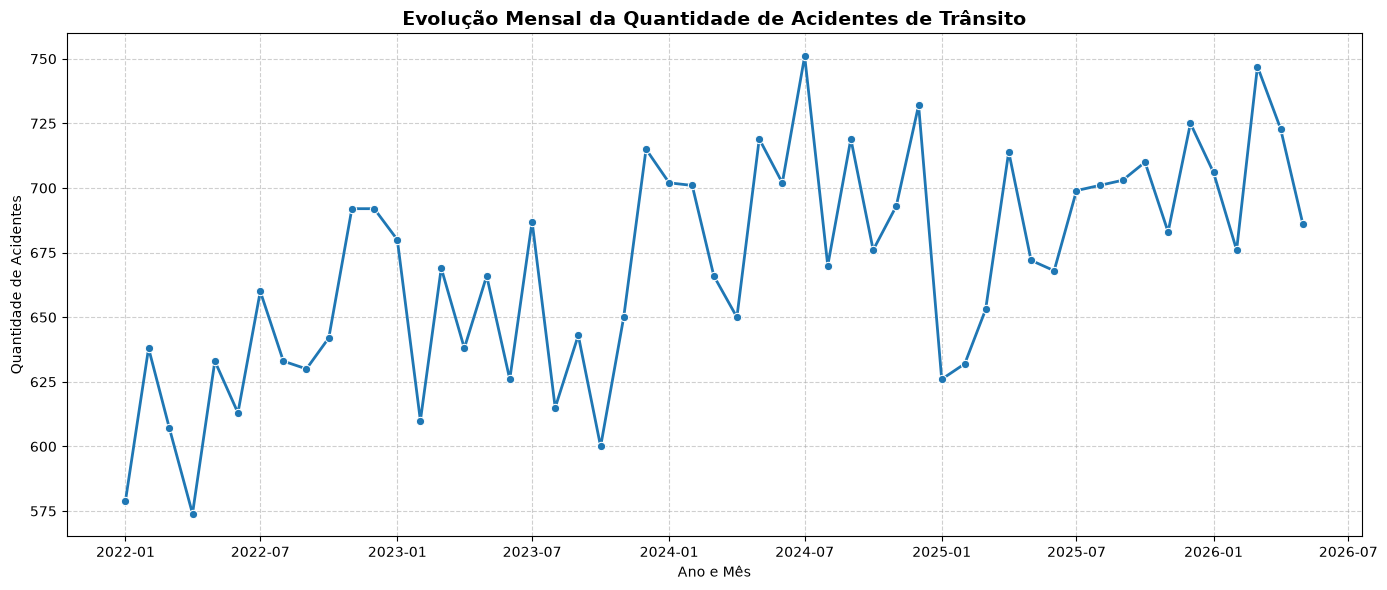

In [15]:
# QUANTIDADE DE ACIDENTES POR MÊS E ANO (Gráfico de Linha)
# Trunca a data para Mês/Ano e converte de volta para timestamp para o eixo X
acidentes_SC["ano_mes"] = (acidentes_SC["data_inversa"].dt.to_period("M").dt.to_timestamp())

acidentes_mes_ano = (acidentes_SC.groupby("ano_mes").size().reset_index(name="total_acidentes"))

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=acidentes_mes_ano,
    x="ano_mes",
    y="total_acidentes",
    marker="o",
    linewidth=2,
    color="#1f77b4",
)

plt.title(
    "Evolução Mensal da Quantidade de Acidentes de Trânsito",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Ano e Mês")
plt.ylabel("Quantidade de Acidentes")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig(Path('../docs/graphics/qtd_acidentes_por_ano'), dpi=300)
plt.show()